Conductor types:
  1 - Solid round
  2 - Stranded, 7 strands
  3 - Stranded, 19 strands
  4 - Stranded, 37 strands
  5 - ACSR 26/7


Select the type of conductor (1-5):  3
Enter conductor radius r (in meters):  0.04
Enter distance between phase 1 and 2 on the crossarm (in meters):  0.5
Enter distance between phase 2 and 3 on the crossarm (in meters):  0.5



--- Transmission Line Parameters ---
Conductor type = Stranded, 19 strands
GMR = 0.030320 m
D13 = 1.000000 m
GMD = 0.629961 m
Inductance per phase = 6.067699e-07 H/m
Capacitance per phase = 2.017984e-11 F/m


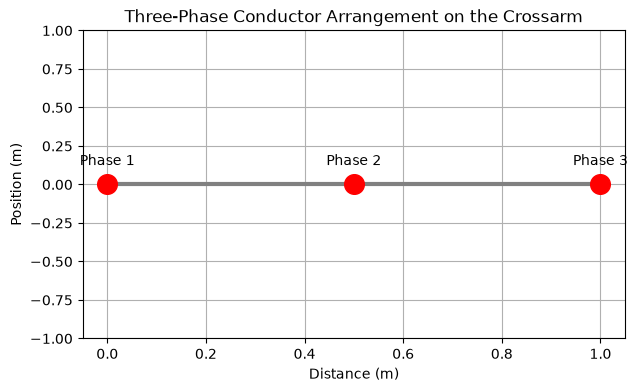

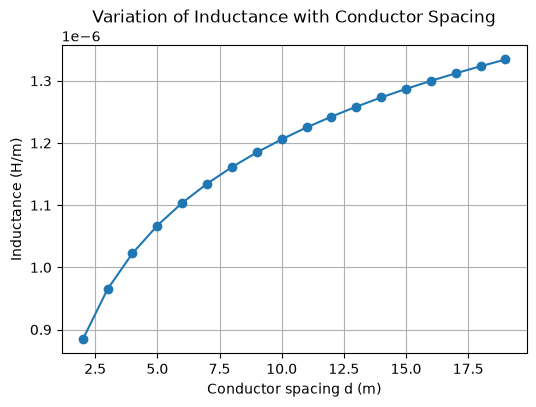

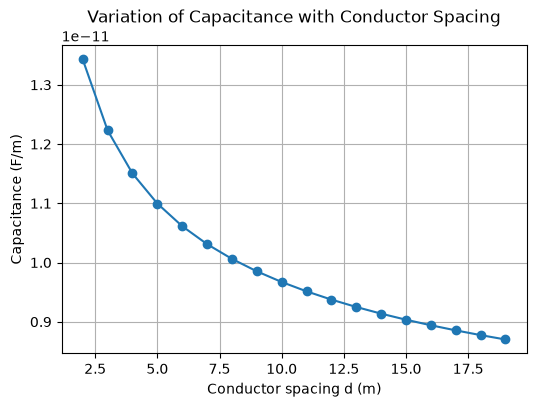


--- Conclusion ---
The inductance increases as conductor spacing increases because GMD increases.
The capacitance decreases as conductor spacing increases because the electric coupling between conductors decreases.


In [3]:
# ============================================================
# CALCULATION OF GMR, GMD, INDUCTANCE AND CAPACITANCE
# FOR A SINGLE-CIRCUIT THREE-PHASE TRANSMISSION LINE
# WITH UNBUNDLED CONDUCTORS
# ============================================================

# Import libraries
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# STEP 1: INPUT CONDUCTOR DATA
# ============================================================

# Types of conductor and their GMR factors:
#
# GMR = factor * physical radius
#
# These are standard approximate values.

conductor_types = {
    "1": ("Solid round", 0.7788),
    "2": ("Stranded, 7 strands", 0.726),
    "3": ("Stranded, 19 strands", 0.758),
    "4": ("Stranded, 37 strands", 0.768),
    "5": ("ACSR 26/7", 0.81),
}

print("Conductor types:")

for key, value in conductor_types.items():
    print(f"  {key} - {value[0]}")

# Ask until a valid option is chosen

choice = input("Select the type of conductor (1-5): ")

while choice not in conductor_types:
    choice = input("Invalid choice. Select the type of conductor (1-5): ")

conductor_name, factor = conductor_types[choice]

# Enter the physical (outer) radius of the conductor in metres
r = float(input("Enter conductor radius r (in meters): "))

# Calculate the Geometric Mean Radius (GMR)

GMR = factor * r


# ============================================================
# STEP 2: INPUT PHYSICAL DIMENSIONS OF THE ARRANGEMENT
# ============================================================

# There is one conductor per phase (no bundles).
# The three phases are in line on a horizontal crossarm.

# Enter the distances between the phase conductors along the crossarm

D12 = float(input(
    "Enter distance between phase 1 and 2 on the crossarm (in meters): "
))

D23 = float(input(
    "Enter distance between phase 2 and 3 on the crossarm (in meters): "
))

# For phases in line, the outer phases are D12 + D23 apart

D13 = D12 + D23


# ============================================================
# STEP 3: CALCULATE GEOMETRIC MEAN DISTANCE (GMD)
# ============================================================

# For a three-phase transmission line:
#
# GMD = (D12 * D23 * D13)^(1/3)

GMD = (D12 * D23 * D13) ** (1 / 3)


# ============================================================
# STEP 4: CALCULATE INDUCTANCE AND CAPACITANCE
# ============================================================

# Inductance per phase per metre:
#
# L = 2e-7 * ln(GMD / GMR)
#
# Unit: H/m

L = 2e-7 * math.log(GMD / GMR)


# Permittivity of free space
epsilon_0 = 8.854e-12


# Capacitance per phase per metre:
#
# C = (2 * pi * epsilon_0) / ln(GMD / r)
#
# Unit: F/m

C = (2 * math.pi * epsilon_0) / math.log(GMD / r)


# ============================================================
# STEP 5: DISPLAY RESULTS
# ============================================================

print("\n--- Transmission Line Parameters ---")

print(f"Conductor type = {conductor_name}")

print(f"GMR = {GMR:.6f} m")

print(f"D13 = {D13:.6f} m")

print(f"GMD = {GMD:.6f} m")

print(f"Inductance per phase = {L:.6e} H/m")

print(f"Capacitance per phase = {C:.6e} F/m")


# ============================================================
# STEP 6: VISUALIZATION OF CONDUCTOR ARRANGEMENT
# ============================================================

# Horizontal conductor arrangement on a crossarm:
#
# Phase 1: x = 0
# Phase 2: x = D12
# Phase 3: x = D12 + D23
#
# All conductors lie on the same line (y = 0).

x_coords = [0, D12, D12 + D23]
y_coords = [0, 0, 0]

labels = ["Phase 1", "Phase 2", "Phase 3"]


# Create the conductor arrangement plot

plt.figure(figsize=(7, 4))

# Crossarm

plt.plot([0, D12 + D23], [0, 0], color="gray", linewidth=3)

# Conductors

plt.scatter(
    x_coords,
    y_coords,
    s=200,
    color="red",
    marker="o",
    zorder=3
)

# Label each conductor

for i, txt in enumerate(labels):
    plt.annotate(
        txt,
        (x_coords[i], y_coords[i]),
        xytext=(0, 14),
        textcoords="offset points",
        fontsize=10,
        ha="center"
    )

plt.title("Three-Phase Conductor Arrangement on the Crossarm")

plt.xlabel("Distance (m)")

plt.ylabel("Position (m)")

plt.ylim(-1, 1)

plt.grid(True)

plt.show()


# ============================================================
# STEP 7: VARIATION OF INDUCTANCE AND CAPACITANCE
# WITH CONDUCTOR SPACING
# ============================================================

# Assume a symmetrical straight-line arrangement:
#
# D12 = d
# D23 = d
# D13 = 2d
#
# Therefore:
#
# GMD = (d * d * 2d)^(1/3)


# Generate conductor spacing values from 2 m to 19 m

distances = [i for i in range(2, 20)]

# Create empty lists to store calculated values

inductances = []

capacitances = []


# Calculate inductance and capacitance for each spacing

for d in distances:

    # Calculate GMD for the symmetrical arrangement

    GMD_var = (d * d * (2 * d)) ** (1 / 3)

    # Calculate inductance

    L_var = 2e-7 * math.log(GMD_var / GMR)

    # Calculate capacitance

    C_var = (
        2 * math.pi * epsilon_0
    ) / math.log(GMD_var / r)

    # Store the results

    inductances.append(L_var)

    capacitances.append(C_var)


# ============================================================
# STEP 8: PLOT VARIATION OF INDUCTANCE
# WITH CONDUCTOR SPACING
# ============================================================

plt.figure(figsize=(6, 4))

plt.plot(
    distances,
    inductances,
    marker="o"
)

plt.title("Variation of Inductance with Conductor Spacing")

plt.xlabel("Conductor spacing d (m)")

plt.ylabel("Inductance (H/m)")

plt.grid(True)

plt.show()


# ============================================================
# STEP 9: PLOT VARIATION OF CAPACITANCE
# WITH CONDUCTOR SPACING
# ============================================================

plt.figure(figsize=(6, 4))

plt.plot(
    distances,
    capacitances,
    marker="o"
)

plt.title("Variation of Capacitance with Conductor Spacing")

plt.xlabel("Conductor spacing d (m)")

plt.ylabel("Capacitance (F/m)")

plt.grid(True)

plt.show()


# ============================================================
# STEP 10: CONCLUSION
# ============================================================

print("\n--- Conclusion ---")

print(
    "The inductance increases as conductor spacing increases "
    "because GMD increases."
)

print(
    "The capacitance decreases as conductor spacing increases "
    "because the electric coupling between conductors decreases."
)